In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_SampleSuperstore.csv")
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,delivery_days,profit_category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,Profit


In [3]:
print(df.shape)
print(df.info())

(9994, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   row_id           9994 non-null   int64  
 1   order_id         9994 non-null   object 
 2   order_date       9994 non-null   object 
 3   ship_date        9994 non-null   object 
 4   ship_mode        9994 non-null   object 
 5   customer_id      9994 non-null   object 
 6   customer_name    9994 non-null   object 
 7   segment          9994 non-null   object 
 8   country          9994 non-null   object 
 9   city             9994 non-null   object 
 10  state            9994 non-null   object 
 11  postal_code      9994 non-null   int64  
 12  region           9994 non-null   object 
 13  product_id       9994 non-null   object 
 14  category         9994 non-null   object 
 15  sub-category     9994 non-null   object 
 16  product_name     9994 non-null   object 
 17  sal

In [4]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit,delivery_days
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000


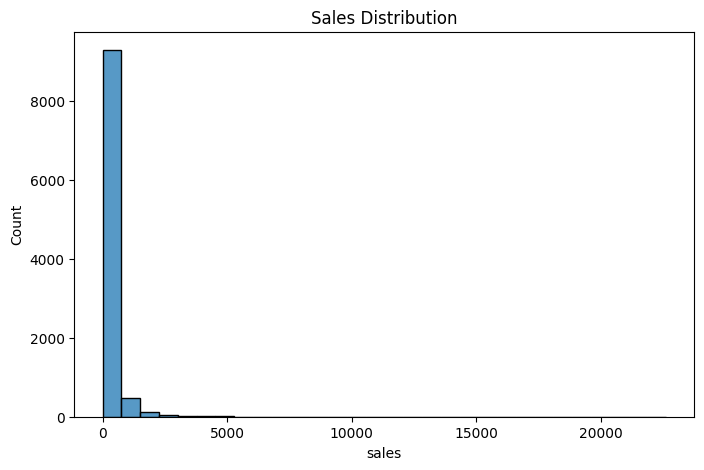

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

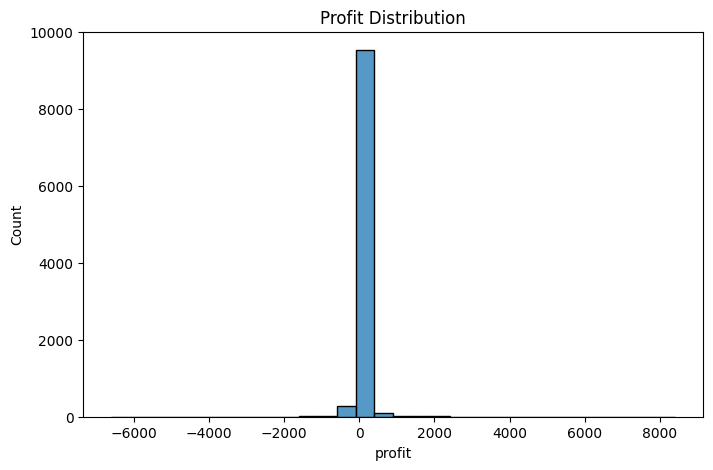

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['profit'], bins=30)
plt.title("Profit Distribution")
plt.show()

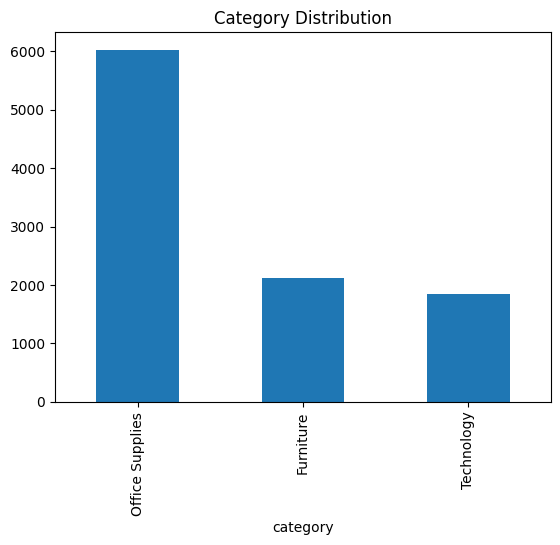

In [7]:
df['category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

In [8]:
print("Total Revenue :",df['sales'].sum())

Total Revenue : 2297200.8603000003


In [9]:
print("Total Profit :",df['profit'].sum())

Total Profit : 286397.0217


In [10]:
print(df['sales'].mean())

229.85800083049833


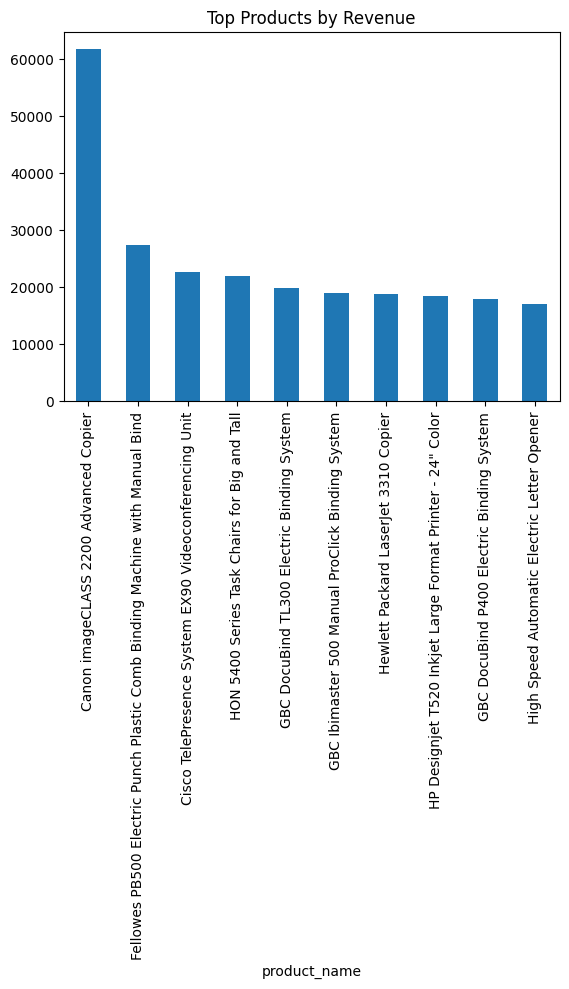

In [11]:
top_products = df.groupby(
    'product_name'
)['sales'].sum().sort_values(
    ascending=False
).head(10)
top_products.plot(kind='bar')
plt.title("Top Products by Revenue")
plt.show()

In [12]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=45c31c15d4b39c0ebe1602e176e29ed67ead0a3bf294f0f571381d0930164d40
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [13]:
from pandasql import sqldf

In [14]:
query = """SELECT product_name,
SUM(sales) as revenue
FROM df
GROUP BY product_name
ORDER BY revenue DESC
LIMIT 5"""
sqldf(query)

,product_name,revenue
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479


In [15]:
query = """SELECT customer_name,
SUM(sales) as revenue
FROM df
GROUP BY customer_name
ORDER BY revenue DESC
LIMIT 5"""
sqldf(query)

,customer_name,revenue
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571


In [16]:
query = """SELECT region,
SUM(profit) as total_profit
FROM df
GROUP BY region
ORDER BY total_profit DESC"""
sqldf(query)

,region,total_profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


In [17]:
query = """SELECT category,
SUM(sales) as revenue
FROM df
GROUP BY category"""
sqldf(query)

,category,revenue
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


In [18]:
query = """SELECT AVG(discount)
FROM df"""
sqldf(query)

,AVG(discount)
0,0.156203


In [19]:
numeric_df = df[
    ['sales',
     'quantity',
     'discount',
     'profit']
]
numeric_df.corr()

,sales,quantity,discount,profit
sales,1.000000,0.200795,-0.028190,0.479064
quantity,0.200795,1.000000,0.008623,0.066253
discount,-0.028190,0.008623,1.000000,-0.219487
profit,0.479064,0.066253,-0.219487,1.000000


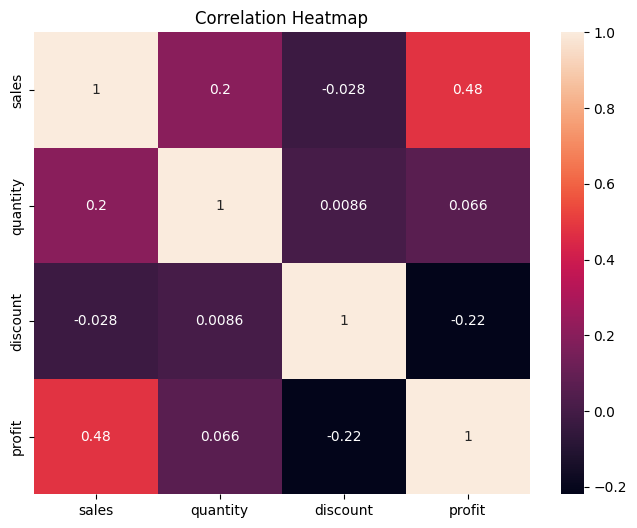

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

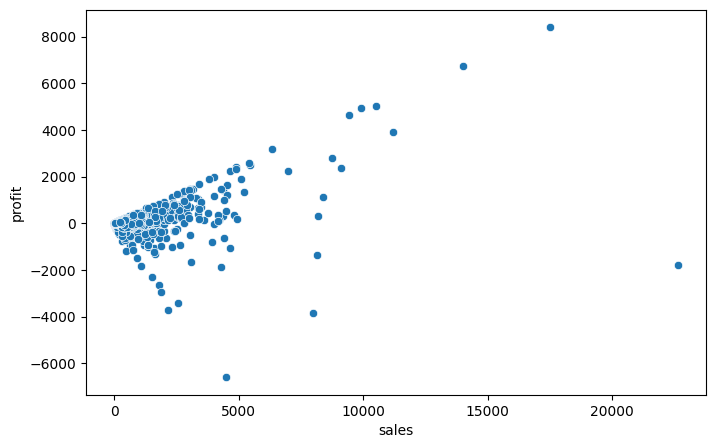

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='sales',
    y='profit'
)
plt.show()

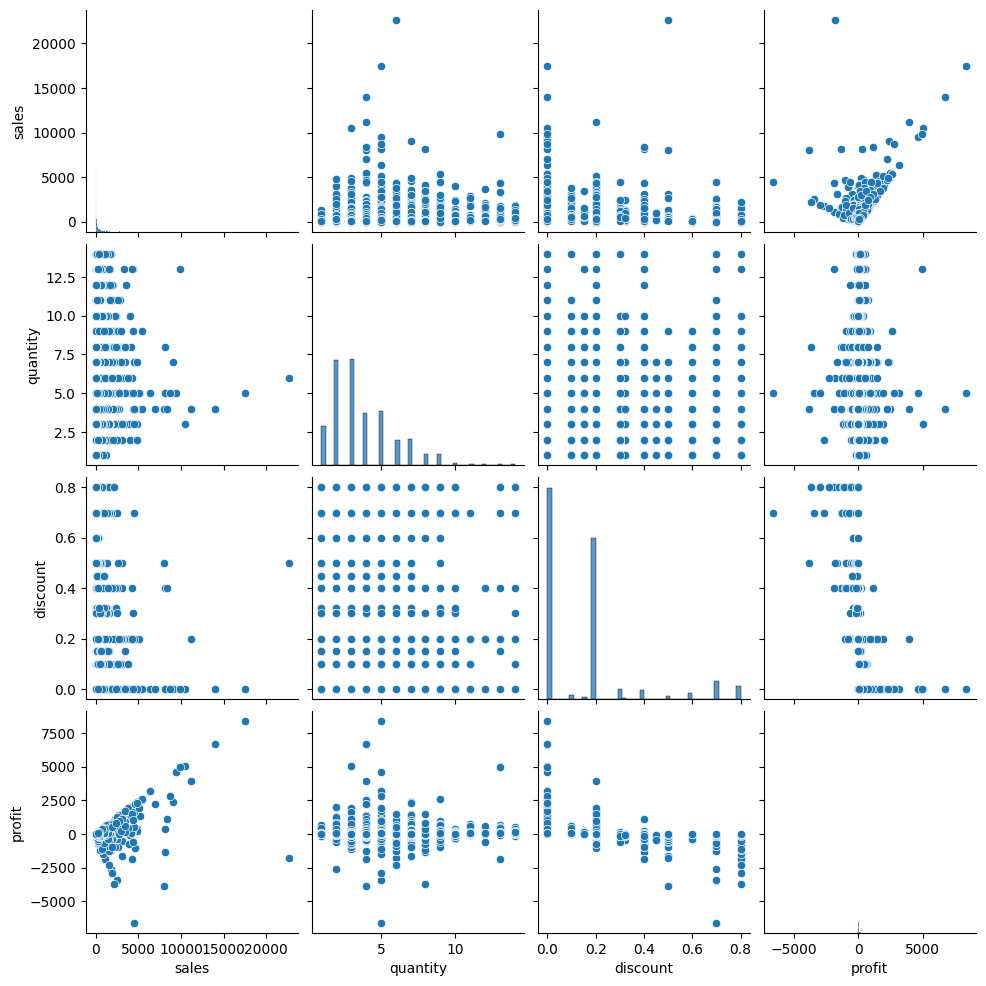

In [22]:
sns.pairplot(
    numeric_df
)
plt.show()

In [23]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
avg_discount = df['discount'].mean()

print(total_sales)
print(total_profit)
print(total_orders)
print(avg_discount)

2297200.8603000003
286397.0217
5009
0.15620272163297977


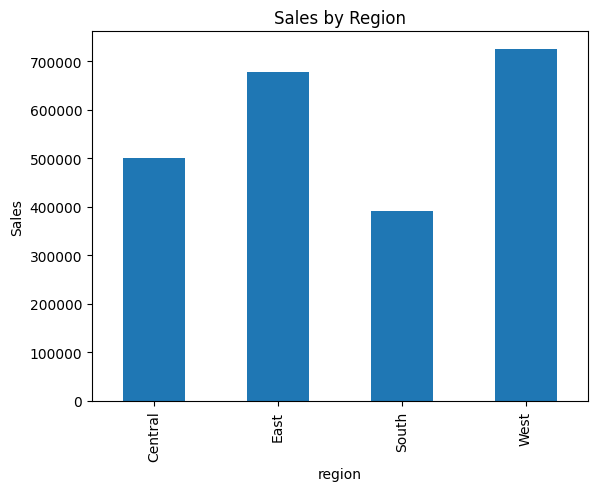

In [24]:
region_sales = df.groupby('region')['sales'].sum()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

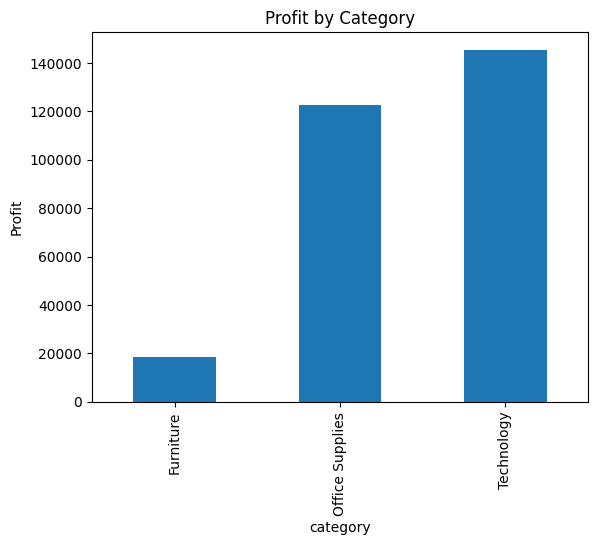

In [25]:
category_profit = df.groupby('category')['profit'].sum()
category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

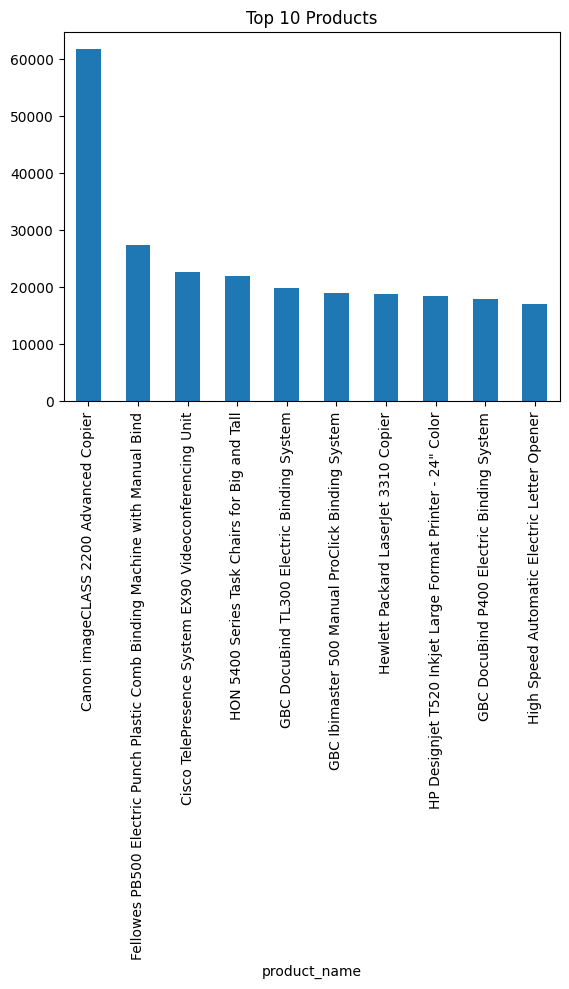

In [26]:
top_products = df.groupby(
    'product_name'
)['sales'].sum().sort_values(
    ascending=False
).head(10)
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

In [27]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [28]:
df['month'] = df['order_date'].dt.month

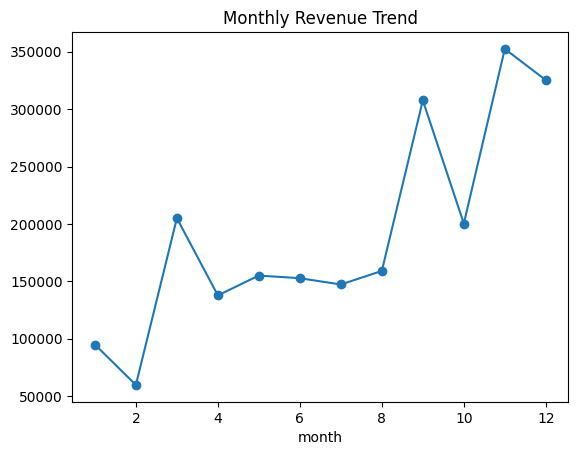

In [29]:
monthly_sales = df.groupby(
    'month'
)['sales'].sum()
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.show()

In [30]:
df.describe()

,row_id,order_date,postal_code,sales,quantity,discount,profit,delivery_days,month
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,7.809686
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,12.000000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,3.284654
